In [1]:
import pandas as pd
import numpy as np
import jax.numpy as jnp
import jax
import numpyro
from sklearn.preprocessing import StandardScaler
from sklearn. decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
from numpyro.infer import Predictive, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam
warnings.filterwarnings('ignore')
numpyro.set_host_device_count(3)

In [2]:
fifa_20 = pd.read_csv('data/players_20.csv')
features = list(fifa_20.columns[fifa_20.dtypes=='int64'])[11:]
target = ['overall']
fifa_20[features].head()

,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,88,95,70,92,88,97,93,94,92,96,...,75,96,33,37,26,6,11,15,14,8
1,84,94,89,83,87,89,81,76,77,92,...,85,95,28,32,24,7,11,15,14,11
2,87,87,62,87,87,96,88,87,81,95,...,90,94,27,26,29,9,9,15,15,11
3,13,11,15,43,13,12,13,14,40,30,...,11,68,27,12,18,87,92,78,90,89
4,81,84,61,89,83,95,83,79,83,94,...,88,91,34,27,22,11,12,6,8,8


In [3]:
scaler_X = StandardScaler()
scaler_X.fit(fifa_20[features].values)

def pre_data(df, scaler_X):

    X = df[features]
    y = np.array(df[target])

    X = scaler_X.transform(X)

    return X,y

X , y = pre_data(fifa_20, scaler_X)

In [4]:
pca = PCA()
pca.fit(X)
CPX = pca.transform(X)

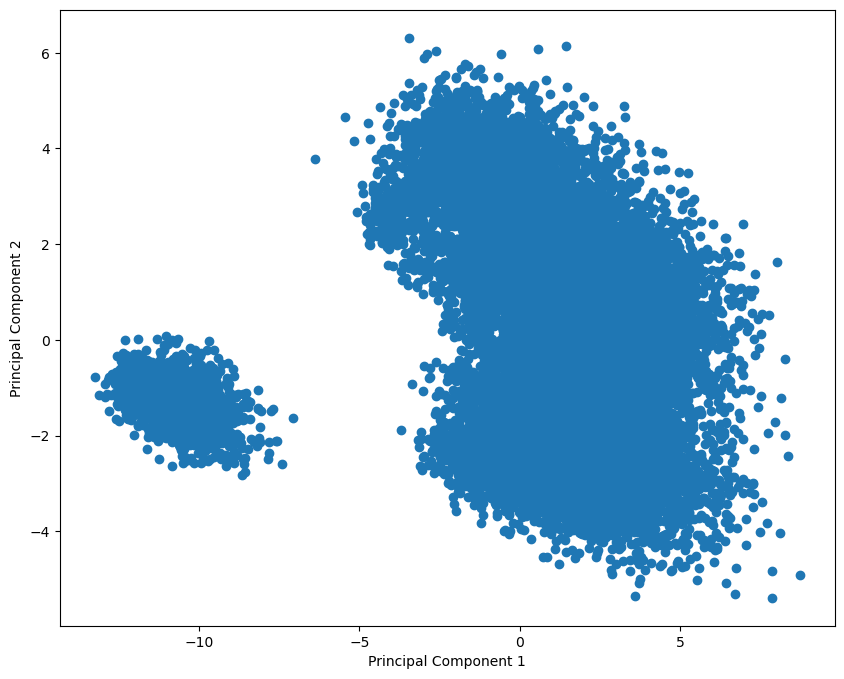

In [5]:
plt.figure(figsize=(10,8))
plt.scatter(CPX[:,0],CPX[:,1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.plot()
plt.show()

In [6]:
kmean = KMeans(n_clusters=4,random_state=1)
kmean.fit(CPX[:,:2])
clusters = kmean.predict(CPX[:,:2])

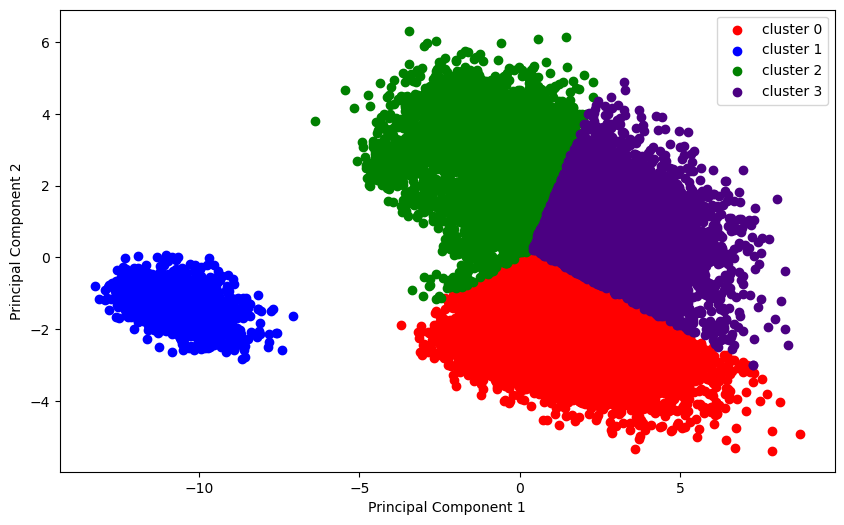

In [7]:
colors=['red','blue','green','indigo']

plt.figure(figsize=(10,6))

for c,col in zip(np.unique(clusters),colors):

    plt.scatter(CPX[clusters==c,0],CPX[clusters==c,1],c=col,label='cluster {}'.format(c))

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.plot()
plt.show()

In [8]:
fifa_20['cluster'] = clusters
fifa_20[['short_name','cluster','player_positions']].query('cluster==0')

,short_name,cluster,player_positions
0,L. Messi,0,"RW, CF, ST"
1,Cristiano Ronaldo,0,"ST, LW"
2,Neymar Jr,0,"LW, CAM"
4,E. Hazard,0,"LW, CF"
9,M. Salah,0,"RW, ST"
...,...,...,...
18248,T. Klysner,0,"LW, LM"
18250,R. Roache,0,ST
18254,E. Jääskeläinen,0,ST
18257,Song Min Kyu,0,LW


In [9]:
fifa_20[['short_name','cluster','nationality','player_positions']].query('cluster==1')

,short_name,cluster,nationality,player_positions
3,J. Oblak,1,Slovenia,GK
6,M. ter Stegen,1,Germany,GK
13,Alisson,1,Brazil,GK
14,De Gea,1,Spain,GK
25,Ederson,1,Brazil,GK
...,...,...,...,...
18231,P. Królczyk,1,Poland,GK
18239,V. Storsve,1,Norway,GK
18251,G. Sykes-Kenworthy,1,England,GK
18259,H. Sveijer,1,Sweden,GK


In [10]:
fifa_20[['short_name','cluster','nationality','player_positions']].query('cluster==2')

,short_name,cluster,nationality,player_positions
11,K. Koulibaly,2,Senegal,CB
57,M. Škriniar,2,Slovakia,CB
77,N. Süle,2,Germany,CB
83,J. Giménez,2,Uruguay,CB
90,K. Manolas,2,Greece,CB
...,...,...,...,...
18273,Shao Shuai,2,China PR,CB
18274,Xiao Mingjie,2,China PR,CB
18275,Zhang Wei,2,China PR,CM
18276,Wang Haijian,2,China PR,CM


In [11]:
fifa_20[['short_name','cluster','nationality','player_positions']].query('cluster==3')

,short_name,cluster,nationality,player_positions
5,K. De Bruyne,3,Belgium,"CAM, CM"
7,V. van Dijk,3,Netherlands,CB
8,L. Modrić,3,Croatia,CM
12,H. Kane,3,England,ST
15,N. Kanté,3,France,"CDM, CM"
...,...,...,...,...
16620,J. Kellermann,3,England,CM
16629,Yao Junsheng,3,China PR,CM
16854,J. Law,3,England,"LWB, LW, ST"
16942,M. Shelton,3,England,CM


In [12]:
fifa_20['position'] = 0

for i in range(fifa_20.shape[0]):

    if fifa_20['cluster'].iloc[i] == 0:

        fifa_20['position'].iloc[i] = 'MED'

    elif fifa_20['cluster'].iloc[i]== 1:

        fifa_20['position'].iloc[i] = 'DEL'

    elif fifa_20['cluster'].iloc[i] == 2:

        fifa_20['position'].iloc[i] = 'POR'

    elif fifa_20['cluster'].iloc[i] == 3:

        fifa_20['position'].iloc[i] = 'DEF'

In [14]:
def recover_original_beta(beta_pca, scaler, pca, y_mean=None, y_std=None):
    """
    Recupera beta_original e intercepto desde:
    - beta_pca (coeficientes en espacio PCA)
    - scaler (StandardScaler)
    - pca (PCA de sklearn)

    Opcional:
    - y_mean, y_std si escalaste y
    """

    # W: (k x p) → necesitamos (p x k)
    W = jnp.array(pca.components_.T)

    # σ (scale)
    scale = jnp.array(scaler.scale_)

    # μ (mean)
    mean = jnp.array(scaler.mean_)

    # Paso 1: volver a espacio estandarizado
    beta_std = W @ beta_pca   # (p,)

    # Paso 2: deshacer scaling
    beta_original = beta_std / scale

    # Paso 3: intercepto
    intercept = -jnp.sum(mean * beta_original)

    # Paso 4: si escalaste y
    if y_mean is not None and y_std is not None:
        beta_original = beta_original * y_std
        intercept = y_mean + y_std * intercept

    return beta_original, intercept

In [52]:
data_gk = fifa_20[fifa_20['position']=='POR']

X_gk = np.array(data_gk[features].values)
y_gk = jnp.array(data_gk[target].values)

#scaler_X_gk = StandardScaler()
#scaler_X_gk.fit(X_gk)

#scale_X_gk = scaler_X_gk.transform(X_gk)

#pca_gk = PCA(n_components=2)
#pca_gk.fit(scale_X_gk)

#pca_X_gk = pca_gk.transform(scale_X_gk)

X_gk_final = np.concatenate(
 (np.ones((len(y_gk), 1)).reshape(-1,1), X_gk),
 axis=1)

X_gk_final = jnp.array(X_gk_final)

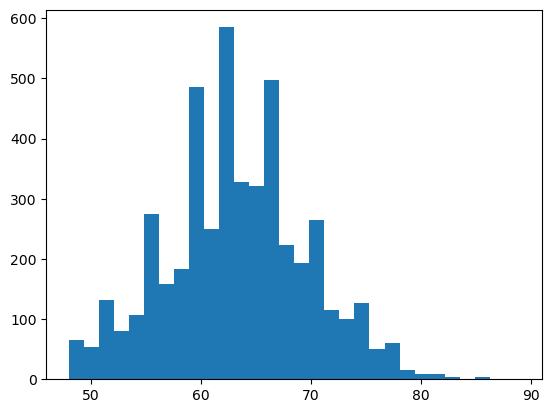

In [53]:
plt.hist(y_gk, bins=30)
plt.show()

In [77]:
def linear_reg_model(X, y=None):

    n, p = X.shape

    beta = numpyro.sample(
        "beta",
        numpyro.distributions.HalfNormal(1.0).expand([p]).to_event(1)
    )

    sigma = numpyro.sample(
        "sigma",
        numpyro.distributions.HalfNormal(1.0)
    )

    mu = jnp.dot(X, beta)

    with numpyro.plate("plate", n, subsample_size=50) as idx:

        mu = jnp.dot(X[idx], beta)

        numpyro.sample(
        "obs",
        numpyro.distributions.Normal(mu, sigma),
        obs=y[idx]
    )

In [78]:
guide = AutoNormal(linear_reg_model)

In [83]:
lr = 3e-3
optimizer = numpyro.optim.Adam(lr)

svi = SVI(
    linear_reg_model,
    guide,
    optimizer,
    loss=Trace_ELBO()
)
rng_key = jax.random.PRNGKey(18081997)

svi_result = svi.run(
    rng_key,
    1000000,
    X_gk_final,
    y_gk,
    progress_bar=True
)

100%|██████████| 1000000/1000000 [06:51<00:00, 2432.46it/s, init loss: 151158849536.0000, avg. loss [950001-1000000]: 773132.8750]


In [84]:


predictive_guide = Predictive(
    guide,
    params=svi_result.params,
    num_samples=1000
)

samples = predictive_guide(jax.random.PRNGKey(1), X_gk_final)

beta_samples = samples["beta"]
sigma_samples = samples["sigma"]

In [85]:
((y_gk[None, :]-jnp.dot(X_gk_final, beta_samples.T))**2).mean(axis=1)

Array([[38.893486, 38.819183, 38.803974, 38.921448, 38.81595 , 38.81057 ,
        38.934834, 38.830944, 38.884296, 38.855705, 38.87172 , 38.832195,
        38.93335 , 38.91382 , 38.91082 , 38.87134 , 38.8228  , 38.93779 ,
        38.851105, 38.909756, 38.782578, 38.8824  , 38.910973, 38.83844 ,
        38.930313, 38.867275, 38.918785, 38.853065, 38.81852 , 38.934727,
        38.852585, 38.81352 , 38.868427, 38.878742, 38.870594, 38.92848 ,
        38.82198 , 38.848946, 38.806168, 38.842674, 38.83268 , 38.86334 ,
        38.856617, 38.919266, 38.83212 , 38.83842 , 38.9104  , 38.83953 ,
        38.88865 , 38.77024 , 38.806786, 38.954197, 38.924957, 38.764267,
        38.84415 , 38.936954, 38.83599 , 38.918095, 38.951218, 38.887596,
        38.781616, 38.93317 , 38.89391 , 38.838566, 38.922   , 38.88359 ,
        38.832813, 38.88267 , 38.914547, 38.942074, 38.889965, 38.8448  ,
        38.85643 , 38.87093 , 38.856606, 38.888924, 38.976933, 38.883316,
        38.804657, 38.83755 , 38.96573

In [23]:
recover_original_beta(beta_pca, scaler_X_gk, pca_gk)

(Array([-1.29983920e-04, -1.69487583e-04,  6.77394428e-06, -1.68462924e-04,
        -1.56743379e-04, -1.67521415e-04, -1.67465507e-04, -1.50279695e-04,
        -1.32495697e-04, -2.01699484e-04, -6.42234081e-05, -6.03541812e-05,
        -1.01528189e-04, -1.14841045e-04, -6.33767704e-05, -8.74027901e-05,
         1.42830240e-05, -7.66654121e-05,  2.76067967e-05, -1.47430983e-04,
        -4.90459061e-05, -4.51236701e-05, -1.43606405e-04, -1.74055414e-04,
        -1.18652664e-04, -7.41618205e-05, -2.74079794e-05, -2.33284536e-05,
        -3.34663673e-05, -3.69714362e-05, -6.60354999e-05, -3.95451971e-05,
        -3.57297504e-05, -4.53973225e-05], dtype=float32),
 Array(0.13078372, dtype=float32))

In [24]:
model_gk.summary_metrics(X_gk_final, y_gk)

ValueError: All input arrays must have the same shape.

In [25]:
model_gk.plot_nll_density(X_gk_final, y_gk)

ValueError: All input arrays must have the same shape.

In [26]:
model_gk.

(Array([63.225433, 63.215694, 63.224915, ..., 63.26364 , 63.25997 ,
        63.262196], dtype=float32),
 Array([63.36746 , 63.34101 , 63.364784, ..., 63.380245, 63.374737,
        63.37698 ], dtype=float32))